# Homework 4: Optional Final Project (A+ Grade Bump)

- This homework template guides you through presenting your final project analysis. 
- Use this notebook to:
    - Generate all visualizations/results and report findings with a pipeline then simply view the results here
    - Generate figures/analysis with imported scripts to produce visualizations/results, and report findings.

> **Note for Beginners:** Running modular Python scripts from inside a Jupyter notebook can sometimes lead to import path or dependency issues if the working directory changes. If you encounter import errors, make sure you add the path of your script folder to `sys.path`, or execute your pipeline directly from your terminal using:
```bash
uv run python src/final_project/first-last/pipeline.py
```

## A. Describe Project

### **Guidance**
- State the policy question, puzzle, or social science problem you are addressing.
- Frame your central hypothesis and the expected relationship between your variables.
- Describe the scope of your analysis (e.g., geographical regions, years covered).
- Highlight the datasets you selected to examine this question.

### **Project Summary**
- **Project Title:** [Fill in your project title here]
- **Student Name:** [Fill in your name here]
- **Policy Relevance Statement:** Birth outcomes such as low birthweight are widely thought to be crucial for children's later development, so policies that shape them carry long-run consequences. Parental leave policy can affect children's birth outcomes by changing household behavior — in particular, the division of childcare and paid work between mothers and fathers.
- **Central Hypothesis:** More generous parental leave policies (longer paid leave for mothers and/or fathers) reduce the probability of low birthweight.

---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
- **Primary Data Source:** OECD Health Statistics — Low Birthweight (`data/hw/hw_3/low_bw.csv`)
- **Secondary Data Source:** OECD Child Well-Being Database — Paid Parental Leave (`data/hw/hw_3/parental_leave.csv`)
- **Variables Retrieved:** Raw OECD SDMX export columns, unchanged (`REF_AREA`, `TIME_PERIOD`, `OBS_VALUE`, `Measure`, etc.) — cleaning and renaming happens in the Manipulate Data step
- **Local Storage Path:** `data/final_project/ruoran-wang/low_bw_raw.csv` and `data/final_project/ruoran-wang/parental_leave_raw.csv`


In [13]:
# Import and run your data acquisition script
import os
import sys
import importlib
from pathlib import Path

sys.path.insert(0, str(Path('../../../src/final_project/ruoran-wang/basic').resolve()))
import data
importlib.reload(data)
low_bw_raw, parental_leave_raw = data.run()
display(low_bw_raw.head())
display(parental_leave_raw.head())


Data acquired and saved to data\final_project\ruoran-wang\low_bw_raw.csv
Data acquired and saved to data\final_project\ruoran-wang\parental_leave_raw.csv


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,DECIMALS,Decimals,OBS_STATUS,Observation status,OBS_STATUS2,Observation status 2,OBS_STATUS3,Observation status 3,UNIT_MULT,Unit multiplier
0,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_STAT@DF_IH_LB(1.1),Infant health: low birthweight,I,AUT,Austria,A,Annual,LOWB,Low birthweight,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
1,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_STAT@DF_IH_LB(1.1),Infant health: low birthweight,I,CHL,Chile,A,Annual,LOWB,Low birthweight,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
2,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_STAT@DF_IH_LB(1.1),Infant health: low birthweight,I,KOR,Korea,A,Annual,LOWB,Low birthweight,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
3,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_STAT@DF_IH_LB(1.1),Infant health: low birthweight,I,LUX,Luxembourg,A,Annual,LOWB,Low birthweight,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units
4,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_STAT@DF_IH_LB(1.1),Infant health: low birthweight,I,MEX,Mexico,A,Annual,LOWB,Low birthweight,...,1,One,NaN,NaN,NaN,NaN,NaN,NaN,0,Units


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,DOMAIN,Domain,...,UNIT_MULT,Unit multiplier,UNIT_MEASURE,Unit of measure,BASE_PER,Base period,DECIMALS,Decimals,POP_GROUP,Population group
0,DATAFLOW,OECD.WISE.CWB:DSD_CWB@DF_CWB(1.0),Child well-being,I,MEX,Mexico,C1_5,Total length of paid paternity and parental le...,C1,Family policies,...,0,Units,WK,Weeks,NaN,NaN,1,One,_Z,Not applicable
1,DATAFLOW,OECD.WISE.CWB:DSD_CWB@DF_CWB(1.0),Child well-being,I,AUS,Australia,C1_4,Total length of paid maternity and parental le...,C1,Family policies,...,0,Units,WK,Weeks,NaN,NaN,1,One,_Z,Not applicable
2,DATAFLOW,OECD.WISE.CWB:DSD_CWB@DF_CWB(1.0),Child well-being,I,AUS,Australia,C1_4,Total length of paid maternity and parental le...,C1,Family policies,...,0,Units,WK,Weeks,NaN,NaN,1,One,_Z,Not applicable
3,DATAFLOW,OECD.WISE.CWB:DSD_CWB@DF_CWB(1.0),Child well-being,I,AUS,Australia,C1_4,Total length of paid maternity and parental le...,C1,Family policies,...,0,Units,WK,Weeks,NaN,NaN,1,One,_Z,Not applicable
4,DATAFLOW,OECD.WISE.CWB:DSD_CWB@DF_CWB(1.0),Child well-being,I,AUS,Australia,C1_4,Total length of paid maternity and parental le...,C1,Family policies,...,0,Units,WK,Weeks,NaN,NaN,1,One,_Z,Not applicable


In [14]:
# Verify the download: show the destination folder structure and confirm files were saved
dest_dir = Path('../../../data/final_project/ruoran-wang').resolve()
print("Destination folder:", dest_dir)
print("Files saved:", os.listdir(dest_dir))


Destination folder: C:\Users\33493\OneDrive\Documents\GitHub\datascience-publicpolicy-2026\data\final_project\ruoran-wang
Files saved: ['low_bw_parental_leave.csv', 'low_bw_parental_leave_clean.csv', 'low_bw_raw.csv', 'parental_leave_raw.csv']


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Preprocessing Summary**
- **Merging Strategy:** Inner merge on `country_code` and `year`, after selecting/renaming `low_bw`'s `REF_AREA`/`TIME_PERIOD`/`OBS_VALUE` and pivoting `parental_leave`'s father/mother leave measures into columns
- **Pre-cleaned Observations:** 673 low birthweight rows and 379 parental leave rows (raw OECD exports)
- **Final Dataset Observations:** 185 clean rows and 5 columns (`country_code`, `year`, `lowb_pct`, `leave_fathers`, `leave_mothers`)
- **Clean Data Path:** `data/final_project/ruoran-wang/low_bw_parental_leave_clean.csv`



In [15]:
import manipulate
df_clean = manipulate.run()
df_clean.head()


Data processed and saved to data\final_project\ruoran-wang\low_bw_parental_leave_clean.csv with shape (185, 5)


,country_code,year,lowb_pct,leave_fathers,leave_mothers
0,AUT,2021,5.9,13.0,60.0
1,NLD,2017,5.9,0.4,16.0
2,SVN,2019,5.9,4.3,52.1
3,CHE,2020,5.9,2.0,14.0
4,CHE,2021,5.9,2.0,14.0


## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.

### **Visualizations & Observations**
- **Figure 1 Key Takeaway:** Across countries, average paid leave reserved for fathers shows little to no clear relationship with a country's average low birthweight rate — countries with both short and long father-leave entitlements span a similar range of birthweight outcomes.
- **Figure 2 Key Takeaway:** Average paid leave available to mothers shows a weak negative pattern with average low birthweight rate — countries offering longer maternity-linked leave tend to cluster toward slightly lower low birthweight rates, though the relationship is loose rather than a tight trend.



Scatter plot saved to reports\final_project\ruoran-wang\low_bw_vs_leave_fathers_scatter.png
Scatter plot saved to reports\final_project\ruoran-wang\low_bw_vs_leave_mothers_scatter.png


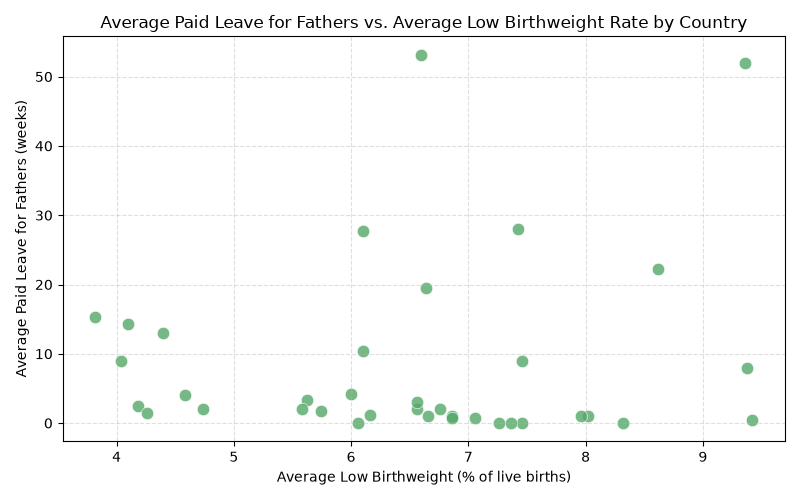

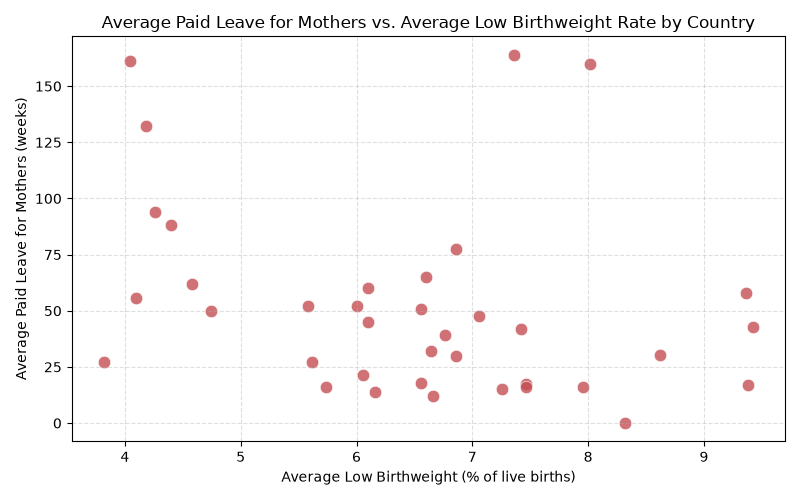

In [16]:
import importlib
import graph
importlib.reload(graph)
fathers_path, mothers_path = graph.run()

from IPython.display import Image, display as ipy_display
ipy_display(Image(filename=str(Path("../../..") / fathers_path)))
ipy_display(Image(filename=str(Path("../../..") / mothers_path)))


## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**
- **Dependent Variable:** `lowb_pct` (low birthweight rate)
- **Independent Variables:** `leave_fathers` and `leave_mothers`, each regressed separately
- **Model Type:** Six regressions in total —
    1. Pooled OLS: `lowb_pct ~ leave_fathers` and `lowb_pct ~ leave_mothers` (no fixed effects)
    2. Panel OLS with **country fixed effects**: `lowb_pct ~ leave_fathers` and `lowb_pct ~ leave_mothers`
    3. Panel OLS with **year fixed effects**: `lowb_pct ~ leave_fathers` and `lowb_pct ~ leave_mothers`
- **Interpretation:** The results are not stable across specifications, and the instability itself is informative. In the pooled OLS and year-fixed-effects models — which are nearly identical to each other — `leave_mothers` is negative and highly significant (coef ≈ -0.0099, p < 0.001), while `leave_fathers` is positive but only marginally significant (coef ≈ 0.016, p ≈ 0.07). Because absorbing year effects barely changes these estimates, the pooled correlation is being driven by persistent *cross-country* differences rather than by year-to-year variation. Once **country fixed effects** are added — absorbing all time-invariant country characteristics (e.g., healthcare system quality, GDP per capita, overall welfare-state generosity) — the pattern reverses: `leave_mothers` shrinks toward zero and loses significance (coef ≈ 0.0034, p ≈ 0.20), while `leave_fathers` flips sign and becomes negative and significant (coef ≈ -0.048, p ≈ 0.002). This suggests the raw negative association between mothers' leave and low birthweight is largely confounded by unobserved, time-invariant country factors rather than reflecting a within-country causal effect, whereas the within-country relationship for fathers' leave — where countries that *expand* father-specific leave over time see lower low birthweight rates — only emerges once that cross-country confounding is removed. **Overall, the evidence only partially and inconsistently supports the hypothesis:** the sign and significance of both variables depend heavily on whether cross-country confounders are absorbed, so these results should be read as suggestive correlations rather than robust causal estimates, and motivate a specification with both country and year fixed effects together (and additional controls) as a next step.


In [17]:
uv run python -m ipykernel install --user --name datascience-publicpolicy-2026 --display-name "datascience-publicpolicy-2026 (.venv)"


Note: you may need to restart the kernel to use updated packages.


c:\Users\33493\anaconda3\python.exe: No module named uv


In [18]:
import importlib
import model
importlib.reload(model)
results = model.run()
display(results)

,Regression,Variable,Coefficient,Std. Error,P-value
0,Pooled OLS,leave_fathers,0.015774,0.008628,0.069136
1,Pooled OLS,leave_mothers,-0.009887,0.002580,0.000175
2,Country FE,leave_fathers,-0.048387,0.015562,0.002252
3,Country FE,leave_mothers,0.003406,0.002659,0.202373
4,Year FE,leave_fathers,0.016056,0.008704,0.066751
5,Year FE,leave_mothers,-0.009964,0.002601,0.000177
